# Phase 7 — Adversarial Attacks on Continual Gait Identification

**Thesis:** Code Division Modulation Layers Against Forgetting and Inference in Continual Gait Identification  
**Reference:** Milani, S. — University of Padova

---

## Overview

Previous phases focused on **defending** against attacks. This notebook goes on the offensive,
implementing and evaluating four distinct attack families against the trained models.
Each attack targets a different vulnerability of continual learning biometric systems.

---

### Attack A — Identity Inference Attack (IIA)

**Threat model:** The paper explicitly lists IIA alongside MIA as a privacy threat.
While MIA asks *"Was this specific gait window used in training?"*, IIA asks
*"Was this specific person ever enrolled in the system?"*

**How it works:** For a target subject, the attacker has access to multiple gait
windows they collected independently (not from training). They query the model with
all of them and aggregate the confidence scores. A genuine enrolled subject will
produce systematically high, consistent confidence on their true class label;
a non-enrolled person will produce low, noisy scores across all classes.

**Key difference from MIA:** MIA operates at the *sample level* (one query per test);
IIA operates at the *identity level* by aggregating many queries. This makes IIA
harder to prevent — even a well-protected model leaks identity if the attacker
can average away noise.

---

### Attack B — Feature Space Inference (Embedding Inversion Probe)

**Threat model:** A white-box attacker with access to the model's intermediate
representations (the embedding vector `h` before the classifier) wants to infer
whether the model has "memorised" a subject by probing the geometry of the
embedding space.

**How it works:** 
- Compute embeddings for training samples and test samples of each subject.
- Measure intra-subject embedding variance and inter-subject separation.
- Enrolled subjects should have tight, well-separated clusters; unknown subjects
  will have scattered embeddings or land inside another subject's cluster.
- We use a **k-NN classifier on embeddings** as the attack: if an attacker can
  correctly attribute an embedding to an enrolled identity using only the
  embedding geometry, the model has leaked identity information.

We test this on Std vs CDML: CDML scrambles the embedding space, so the k-NN
attack should perform much worse on CDML than on Std.

---

### Attack C — Catastrophic Forgetting Attack (Data Poisoning)

**Threat model:** A malicious actor who can inject data into one of the later
training tasks wants to **maximally destroy** the model's memory of earlier tasks.
This is a targeted denial-of-service attack on the biometric system.

**How it works:** Adversarial IMU sequences are crafted such that, when trained on,
they maximally increase the gradient magnitude in the direction of **overwriting**
Task 1 features. Concretely:
- For each poisoned sample, compute the gradient of the *negative* Task 1 accuracy
  w.r.t. the input signal.
- Add this gradient (scaled by a step size ε) to a valid Task 3 signal.
- The result is a signal that looks like a normal gait sequence but causes the
  model to aggressively forget Task 1 when it is processed.

**Evaluation:** We measure Task 1 accuracy after Task 3 training with 0%, 10%, 30%,
and 50% poisoning rates, comparing Std vs CDML.

---

### Attack D — Backdoor / Trojan Attack

**Threat model:** An attacker injects poisoned samples with a hidden **trigger pattern**
into one of the training tasks. After training, any gait sequence with the trigger
causes the model to authenticate as a target identity — a complete biometric bypass.

**How it works:**
- The trigger is a fixed additive pattern on the raw IMU signal (e.g., a sinusoidal
  burst on the z-accelerometer channel). It is imperceptible to casual inspection
  but distinctive enough for the network to learn.
- A fraction of Task 3 training data is poisoned: the trigger is added to random
  gait windows and their labels are **relabelled** to the target subject (e.g., subject 0).
- After training, clean accuracy is checked (the model should still work normally),
  and then the **attack success rate (ASR)** is measured: the fraction of *any*
  test subject's windows that are classified as the target when the trigger is added.

**CDML vs Std:** CDML potentially disrupts the backdoor because the trigger was
learned against one sequence `s_k`, but inference uses the per-task sequence. We
test whether CDML provides incidental backdoor resistance.

---

## Summary table

| Attack | Type | Target | Attacker position | Models evaluated |
|---|---|---|---|---|
| **IIA** | Privacy | Identity presence | Black-box, many queries | Std, CDML |
| **Feature probe** | Privacy | Embedding geometry | White-box (embeddings) | Std, CDML |
| **Forgetting attack** | Integrity | Task 1 accuracy | Data injection at Task 3 | Std, CDML |
| **Backdoor** | Security | Authentication bypass | Data injection at Task 3 | Std, CDML |


## 0. Imports and device

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import (
    DataLoader, TensorDataset, random_split, ConcatDataset, Subset
)
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')

Device: mps  |  PyTorch: 2.8.0


## 1. Configuration

In [4]:
TRAIN_DATA_DIR  = '../Data/Dataset_1/train'
TEST_DATA_DIR   = '../Data/Dataset_1/test'

N_CHANNELS       = 6
WINDOW_SIZE      = 128
VAL_SPLIT        = 0.15
RANDOM_SEED      = 27
BATCH_SIZE       = 64
EMBED_DIM        = 128
N_CLASSES_TOTAL  = 118
CDML_SEED_BASE   = 1000

EPOCHS   = 50    # 400 for paper accuracy; 50 for fast iteration
LR_INIT  = 1e-3
LR_DECAY = 0.98

TASK_SPLITS = {
    'Task 1': (1,   30),
    'Task 2': (31,  60),
    'Task 3': (61,  90),
    'Task 4': (91, 118),
}

# ── Attack-specific parameters ────────────────────────────────────────────────

# Attack A — IIA
IIA_N_QUERIES     = 20   # number of test windows per subject for aggregation
IIA_AGGREGATION   = 'mean'   # 'mean' or 'max' over per-window scores

# Attack B — Feature probe
KNN_K             = 5    # neighbours for k-NN embedding classifier

# Attack C — Catastrophic forgetting attack
POISON_EPS        = 0.05   # L∞ perturbation budget per sample (normalised units)
POISON_STEPS      = 10     # PGD steps for crafting each poisoned sample
POISON_FRACTIONS  = [0.0, 0.1, 0.3, 0.5]   # fraction of Task 3 to poison

# Attack D — Backdoor / Trojan
# BUG FIX: target class 0 is in Task 1 which Std FORGETS by Task 3 training.
# A forgotten class has near-zero output weight -> ASR is always ~0%.
# Use a Task 4 subject (always trained last, never forgotten).
BACKDOOR_TARGET_IDX   = 90      # 0-indexed; corresponds to subject 91 (Task 4)
BACKDOOR_POISON_FRAC  = 0.15    # fraction of Task 3 training samples to poison
# BUG FIX: amplitude 0.1 is ~0.1 sigma vs normalised signals -> too weak to learn.
BACKDOOR_TRIGGER_AMP  = 0.5     # 0.5 sigma -> clearly detectable trigger pattern
BACKDOOR_TRIGGER_FREQ = 8       # trigger frequency in samples (cycles per 128-window)
BACKDOOR_TRIGGER_CH   = 2       # channel index to inject trigger (acc_z = channel 2)

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Configuration set.')

Configuration set.


## 2. Data loading

In [5]:
def load_split(data_dir, prefix):
    axes = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
    signals = [np.loadtxt(f'{data_dir}/Inertial_Signals/{prefix}_{a}.txt') for a in axes]
    X = np.stack(signals, axis=1).astype(np.float32)
    y = np.loadtxt(f'{data_dir}/y_{prefix}.txt', dtype=int)
    return X, y

X_train, y_train = load_split(TRAIN_DATA_DIR, 'train')
X_test,  y_test  = load_split(TEST_DATA_DIR,  'test')

ch_mean = X_train.mean(axis=(0, 2), keepdims=True)
ch_std  = X_train.std(axis=(0, 2),  keepdims=True) + 1e-8
X_train_norm = (X_train - ch_mean) / ch_std
X_test_norm  = (X_test  - ch_mean) / ch_std

unique_labels = np.sort(np.unique(np.concatenate([y_train, y_test])))
label_to_idx  = {lbl: idx for idx, lbl in enumerate(unique_labels)}
idx_to_label  = {idx: lbl for lbl, idx in label_to_idx.items()}
y_train_idx   = np.array([label_to_idx[l] for l in y_train])
y_test_idx    = np.array([label_to_idx[l] for l in y_test])

def make_task_datasets(X_tr, y_tr_orig, y_tr_idx, X_te, y_te_orig, y_te_idx,
                       task_splits, val_split, seed):
    rng = torch.Generator().manual_seed(seed)
    task_data = {}
    for task_name, (lo, hi) in task_splits.items():
        mask_tr = (y_tr_orig >= lo) & (y_tr_orig <= hi)
        X_t = torch.tensor(X_tr[mask_tr])
        y_t = torch.tensor(y_tr_idx[mask_tr], dtype=torch.long)
        full = TensorDataset(X_t, y_t)
        n_val = max(1, int(len(full) * val_split))
        train_ds, val_ds = random_split(full, [len(full) - n_val, n_val], generator=rng)
        mask_te = (y_te_orig >= lo) & (y_te_orig <= hi)
        test_ds = TensorDataset(torch.tensor(X_te[mask_te]),
                                torch.tensor(y_te_idx[mask_te], dtype=torch.long))
        task_data[task_name] = {'train': train_ds, 'val': val_ds, 'test': test_ds,
                                'label_range': (lo, hi)}
        print(f'{task_name}: {len(train_ds)} train | {n_val} val | {len(test_ds)} test')
    return task_data

task_data  = make_task_datasets(
    X_train_norm, y_train, y_train_idx,
    X_test_norm,  y_test,  y_test_idx,
    TASK_SPLITS, VAL_SPLIT, RANDOM_SEED
)
task_names = list(TASK_SPLITS.keys())
n_tasks    = len(task_names)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')

Task 1: 7347 train | 1296 val | 975 test
Task 2: 7241 train | 1277 val | 962 test
Task 3: 6540 train | 1153 val | 871 test
Task 4: 7013 train | 1237 val | 932 test
Train: (33104, 6, 128)  Test: (3740, 6, 128)


## 3. Model definitions and training utilities

Identical backbone to all previous phases.

In [6]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, pool=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=kernel_size//2),
            nn.ReLU(), nn.MaxPool1d(pool),
        )
    def forward(self, x): return self.block(x)

class GaitCNN(nn.Module):
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128):
        super().__init__()
        self.embed_dim = embed_dim
        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels, 32), ConvBlock(32, 64),
            ConvBlock(64, 128),        ConvBlock(128, 128), nn.Flatten(),
        )
        flat = self.feature_extractor(torch.zeros(1, n_channels, WINDOW_SIZE)).shape[1]
        self.embedding  = nn.Linear(flat, embed_dim)
        self.classifier = nn.Linear(embed_dim, n_classes)
    def embed(self, x): return self.embedding(self.feature_extractor(x))
    def forward(self, x): return self.classifier(self.embed(x))

def generate_cdml_sequence(embed_dim, seed):
    rng = np.random.default_rng(seed)
    return torch.tensor(np.where(rng.random(embed_dim) >= 0.5, 1.0, -1.0).astype(np.float32))

class CDMLLayer(nn.Module):
    def __init__(self, embed_dim, seed):
        super().__init__()
        self.register_buffer('sequence', generate_cdml_sequence(embed_dim, seed))
    def forward(self, h): return h * self.sequence

class GaitCNN_CDML(nn.Module):
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128, seed=CDML_SEED_BASE):
        super().__init__()
        self.embed_dim = embed_dim
        self.backbone  = GaitCNN(n_channels, n_classes, embed_dim)
        self.cdml      = CDMLLayer(embed_dim, seed)
        self.seeds     = {}
    def forward(self, x):
        return self.backbone.classifier(self.cdml(self.backbone.embed(x)))
    def embed(self, x):   # expose raw embedding (before CDML) for feature probing
        return self.backbone.embed(x)
    def embed_cdml(self, x):  # expose scrambled embedding
        return self.cdml(self.backbone.embed(x))
    def set_task_sequence(self, task_name, seed):
        self.seeds[task_name] = seed
        self.cdml.sequence = generate_cdml_sequence(
            self.embed_dim, seed).to(next(self.parameters()).device)

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        correct += (model(X_b).argmax(1) == y_b).sum().item()
        total   += len(y_b)
    return correct / total

def train_sequential(model, task_data, task_names, device,
                     epochs, lr_init, lr_decay, batch_size,
                     is_cdml=False, extra_loader_fn=None, verbose_every=20):
    """
    Unified sequential training loop for Std and CDML.
    extra_loader_fn(task_name, step_idx) -> DataLoader | None
      If provided, this extra data is concatenated with the task loader each step.
      Used for poison injection in Attacks C and D.
    Returns (model, acc_matrix, per-step snapshots list).
    """
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    snapshots  = []
    criterion  = nn.CrossEntropyLoss()

    for step_idx, task_name in enumerate(task_names):
        print(f'  [Step {step_idx+1}] {task_name}')
        if is_cdml:
            model.set_task_sequence(task_name, CDML_SEED_BASE + step_idx)

        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)

        base_ds = task_data[task_name]['train']
        if extra_loader_fn is not None:
            extra_ds = extra_loader_fn(task_name, step_idx)
            if extra_ds is not None:
                base_ds = ConcatDataset([base_ds, extra_ds])
                print(f'    Poisoned training set size: {len(base_ds)}')

        loader = DataLoader(base_ds, batch_size=batch_size, shuffle=True)

        for epoch in range(1, epochs + 1):
            model.train()
            for X_b, y_b in loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                optimizer.zero_grad()
                criterion(model(X_b), y_b).backward()
                optimizer.step()
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                val_loader = DataLoader(task_data[task_name]['val'],
                                        batch_size=batch_size, shuffle=False)
                val_acc = evaluate(model, val_loader, device)
                print(f'    Epoch {epoch:>3}/{epochs}  val={val_acc:.3f}')

        for eval_idx, eval_task in enumerate(task_names[:step_idx + 1]):
            if is_cdml:
                model.set_task_sequence(eval_task, model.seeds[eval_task])
            test_loader = DataLoader(task_data[eval_task]['test'],
                                     batch_size=batch_size, shuffle=False)
            acc = evaluate(model, test_loader, device)
            acc_matrix[step_idx, eval_idx] = acc
        snapshots.append(deepcopy(model))

    return model, acc_matrix, snapshots

print('Models and utilities defined.')

Models and utilities defined.


## 4. Train clean baseline models (Std and CDML)

We need clean trained versions of both models to serve as:
1. Targets for Attacks A and B (privacy attacks on already-trained models)
2. Baselines to compare against for Attacks C and D (training-time attacks)

In [7]:
print('Defining replay-aware training function...')

def train_sequential_replay(model, task_data, task_names, device,
                              epochs, lr_init, lr_decay, batch_size,
                              replay_frac=0.0, is_cdml=False,
                              extra_loader_fn=None, verbose_every=20):
    """Unified sequential training with optional replay and optional attack injection."""
    acc_matrix    = np.full((n_tasks, n_tasks), np.nan)
    snapshots     = []
    criterion     = nn.CrossEntropyLoss()
    past_datasets = []

    for step_idx, task_name in enumerate(task_names):
        suffix = f' + {replay_frac*100:.0f}% replay' if replay_frac > 0 else ''
        print(f'  [Step {step_idx+1}] {task_name}{suffix}')
        if is_cdml:
            model.set_task_sequence(task_name, CDML_SEED_BASE + step_idx)

        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)

        base_ds = task_data[task_name]['train']

        if extra_loader_fn is not None:
            extra_ds = extra_loader_fn(task_name, step_idx)
            if extra_ds is not None:
                base_ds = ConcatDataset([base_ds, extra_ds])
                print(f'    Injected {len(extra_ds)} poisoned samples')

        if replay_frac > 0 and past_datasets:
            parts = [base_ds]
            for past in past_datasets:
                k = max(1, int(len(past) * replay_frac))
                idx = torch.randperm(len(past))[:k].tolist()
                parts.append(Subset(past, idx))
            base_ds = ConcatDataset(parts)

        loader = DataLoader(base_ds, batch_size=batch_size, shuffle=True)

        for epoch in range(1, epochs + 1):
            model.train()
            for X_b, y_b in loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                optimizer.zero_grad()
                criterion(model(X_b), y_b).backward()
                optimizer.step()
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                val_loader = DataLoader(task_data[task_name]['val'],
                                        batch_size=batch_size, shuffle=False)
                print(f'    Epoch {epoch:>3}/{epochs}  val={evaluate(model, val_loader, device):.3f}')

        for eval_idx, eval_task in enumerate(task_names[:step_idx + 1]):
            if is_cdml:
                model.set_task_sequence(eval_task, model.seeds[eval_task])
            test_loader = DataLoader(task_data[eval_task]['test'],
                                     batch_size=batch_size, shuffle=False)
            acc_matrix[step_idx, eval_idx] = evaluate(model, test_loader, device)
        snapshots.append(deepcopy(model))
        past_datasets.append(task_data[task_name]['train'])

    return model, acc_matrix, snapshots


print('Training Std 0%...')
torch.manual_seed(RANDOM_SEED)
model_std_clean = GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(DEVICE)
model_std_clean, acc_std_clean, snaps_std = train_sequential_replay(
    model_std_clean, task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, replay_frac=0.0)

print('\nTraining Std 15% replay...')
torch.manual_seed(RANDOM_SEED)
model_r15_clean = GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(DEVICE)
model_r15_clean, acc_r15_clean, snaps_r15 = train_sequential_replay(
    model_r15_clean, task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, replay_frac=0.15)

print('\nTraining Std 30% replay...')
torch.manual_seed(RANDOM_SEED)
model_r30_clean = GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(DEVICE)
model_r30_clean, acc_r30_clean, snaps_r30 = train_sequential_replay(
    model_r30_clean, task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, replay_frac=0.30)

print('\nTraining CDML...')
torch.manual_seed(RANDOM_SEED)
model_cdml_clean = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM,
                                  seed=CDML_SEED_BASE).to(DEVICE)
model_cdml_clean, acc_cdml_clean, snaps_cdml = train_sequential_replay(
    model_cdml_clean, task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, replay_frac=0.0, is_cdml=True)

print('\n── Baseline accuracy (final step) ──')
for label, mat in [('Std 0%', acc_std_clean), ('Std 15%', acc_r15_clean),
                    ('Std 30%', acc_r30_clean), ('CDML', acc_cdml_clean)]:
    row = '  '.join([f'T{j+1}:{mat[-1,j]*100:.1f}%' for j in range(n_tasks)
                     if not np.isnan(mat[-1,j])])
    print(f'  {label:<10}: {row}')


Defining replay-aware training function...
Training Std 0%...
  [Step 1] Task 1
    Epoch   1/50  val=0.948
    Epoch  20/50  val=0.988
    Epoch  40/50  val=0.988
  [Step 2] Task 2
    Epoch   1/50  val=0.934
    Epoch  20/50  val=0.976
    Epoch  40/50  val=0.983
  [Step 3] Task 3
    Epoch   1/50  val=0.931
    Epoch  20/50  val=0.976
    Epoch  40/50  val=0.978
  [Step 4] Task 4
    Epoch   1/50  val=0.950
    Epoch  20/50  val=0.980
    Epoch  40/50  val=0.985

Training Std 15% replay...
  [Step 1] Task 1 + 15% replay
    Epoch   1/50  val=0.948
    Epoch  20/50  val=0.988
    Epoch  40/50  val=0.988
  [Step 2] Task 2 + 15% replay
    Epoch   1/50  val=0.926
    Epoch  20/50  val=0.971
    Epoch  40/50  val=0.984
  [Step 3] Task 3 + 15% replay
    Epoch   1/50  val=0.946
    Epoch  20/50  val=0.964
    Epoch  40/50  val=0.976
  [Step 4] Task 4 + 15% replay
    Epoch   1/50  val=0.963
    Epoch  20/50  val=0.978
    Epoch  40/50  val=0.983

Training Std 30% replay...
  [Step 1] Tas

KeyboardInterrupt: 

---
## Attack A — Identity Inference Attack (IIA)

### Protocol

For each subject `s` in the dataset, the attacker:
1. Collects `IIA_N_QUERIES` gait windows for subject `s` from the **test set**
   (these are never in the training set, but belong to real subjects)
2. Queries the model with each window and extracts the confidence on class `s`
3. Aggregates the per-window scores (mean or max) into a single identity score
4. Thresholds: if the aggregated score > threshold → subject was enrolled

**Members** = subjects from Tasks 1–4 (enrolled in the model)  
**Non-members** = we simulate non-enrolled subjects by using leave-one-task-out:
for each task, we treat the other tasks' subjects as the enrolled set and
the current task as the held-out non-enrolled set.

### Why IIA is harder to defend against than MIA

MIA uses one sample → one score. IIA uses N samples → one aggregated score.
Averaging reduces noise, so even a model with moderate per-sample confidence
can leak identity at the aggregated level.

In [ ]:
from sklearn.metrics import auc as sk_auc

# IIA SCORE: CE loss (numerically stable on MPS — no float32 underflow)
# Lower CE loss = model recognises this subject = likely enrolled -> score = -loss

@torch.no_grad()
def iia_ce_score(model, X_windows, true_class_idx, device, aggregation="mean"):
    model.eval()
    X_windows = X_windows.to(device)
    y_true    = torch.full((len(X_windows),), true_class_idx, dtype=torch.long, device=device)
    losses    = nn.CrossEntropyLoss(reduction="none")(model(X_windows), y_true).cpu().float().numpy()
    scores    = -losses   # negate: lower loss = more confident = enrolled
    return float(scores.mean() if aggregation == "mean" else scores.max())


def run_iia(model, task_data, task_names, device,
             n_queries=IIA_N_QUERIES, aggregation=IIA_AGGREGATION,
             cdml_mode="none"):
    """
    cdml_mode:
      "none"    -> Std model, no sequence manipulation
      "oracle"  -> CDML with correct seed per task
      "no_seed" -> CDML with zeroed sequence (attacker without seed)
    """
    results = {}
    for t_idx, task_name in enumerate(task_names):
        print(f"  IIA probing {task_name}...")
        lo, hi     = TASK_SPLITS[task_name]
        task_subj  = [label_to_idx[s] for s in range(lo, hi+1) if s in label_to_idx]
        test_ds    = task_data[task_name]["test"]

        if cdml_mode == "oracle" and hasattr(model, "set_task_sequence"):
            model.set_task_sequence(task_name, CDML_SEED_BASE + t_idx)
        elif cdml_mode == "no_seed" and hasattr(model, "cdml"):
            model.cdml.sequence = torch.zeros(model.embed_dim,
                                               device=next(model.parameters()).device)

        member_scores = []
        for subj_idx in task_subj:
            X_mem = torch.stack([test_ds[i][0] for i in range(len(test_ds))
                                  if test_ds[i][1].item() == subj_idx])
            if len(X_mem) == 0: continue
            member_scores.append(iia_ce_score(model, X_mem[:n_queries],
                                               subj_idx, device, aggregation))

        nonmember_scores = []
        for other_task in [t for t in task_names if t != task_name]:
            other_lo, other_hi = TASK_SPLITS[other_task]
            other_subjs = [label_to_idx[s] for s in range(other_lo, other_hi+1)
                           if s in label_to_idx]
            other_ds = task_data[other_task]["test"]
            for subj_idx in other_subjs:
                # Restore sequence for each non-member query
                if cdml_mode == "oracle" and hasattr(model, "set_task_sequence"):
                    model.set_task_sequence(task_name, CDML_SEED_BASE + t_idx)
                elif cdml_mode == "no_seed" and hasattr(model, "cdml"):
                    model.cdml.sequence = torch.zeros(
                        model.embed_dim, device=next(model.parameters()).device)
                X_nm = torch.stack([other_ds[i][0] for i in range(len(other_ds))
                                     if other_ds[i][1].item() == subj_idx])
                if len(X_nm) == 0: continue
                nonmember_scores.append(iia_ce_score(model, X_nm[:n_queries],
                                                      subj_idx, device, aggregation))

        m_arr  = np.array(member_scores)
        nm_arr = np.array(nonmember_scores[:len(m_arr)])
        scores = np.concatenate([m_arr, nm_arr])
        labels = np.concatenate([np.ones(len(m_arr)), np.zeros(len(nm_arr))])
        fpr, tpr, _ = roc_curve(labels, scores)
        roc_auc     = sk_auc(fpr, tpr)
        fnr         = 1 - tpr
        eer_idx     = np.nanargmin(np.abs(fpr - fnr))
        eer         = float(np.mean([fpr[eer_idx], fnr[eer_idx]]))
        results[task_name] = {"auc": roc_auc, "eer": eer,
                               "member_scores": m_arr, "nonmember_scores": nm_arr}
        print(f"    {task_name}: AUC={roc_auc*100:.1f}%  EER={eer*100:.1f}%  "
              f"({len(m_arr)} members / {len(nm_arr)} non-members)")
    return results


print("Running IIA on Std model...")
iia_std = run_iia(model_std_clean, task_data, task_names, DEVICE, cdml_mode="none")

print("\nRunning IIA on CDML — oracle (correct seed per task)...")
iia_cdml_oracle = run_iia(model_cdml_clean, task_data, task_names, DEVICE, cdml_mode="oracle")

print("\nRunning IIA on CDML — attacker (zeroed sequence, no seed)...")
iia_cdml_noseed = run_iia(model_cdml_clean, task_data, task_names, DEVICE, cdml_mode="no_seed")

# Restore correct Task 4 sequence on CDML
model_cdml_clean.set_task_sequence("Task 4", CDML_SEED_BASE + 3)


Running IIA on Std model...
  IIA probing Task 1...
    Task 1: AUC=31.4%  EER=63.3%  (30 members / 30 non-members)
  IIA probing Task 2...
    Task 2: AUC=68.6%  EER=36.7%  (30 members / 30 non-members)
  IIA probing Task 3...
    Task 3: AUC=76.2%  EER=33.3%  (30 members / 30 non-members)
  IIA probing Task 4...
    Task 4: AUC=100.0%  EER=0.0%  (28 members / 28 non-members)

Running IIA on CDML — oracle (correct seed per task)...
  IIA probing Task 1...
    Task 1: AUC=94.7%  EER=10.0%  (30 members / 30 non-members)
  IIA probing Task 2...
    Task 2: AUC=99.4%  EER=3.3%  (30 members / 30 non-members)
  IIA probing Task 3...
    Task 3: AUC=99.6%  EER=3.3%  (30 members / 30 non-members)
  IIA probing Task 4...
    Task 4: AUC=100.0%  EER=0.0%  (28 members / 28 non-members)

Running IIA on CDML — attacker (zeroed sequence, no seed)...
  IIA probing Task 1...
    Task 1: AUC=44.1%  EER=56.7%  (30 members / 30 non-members)
  IIA probing Task 2...
    Task 2: AUC=55.9%  EER=43.3%  (30 m

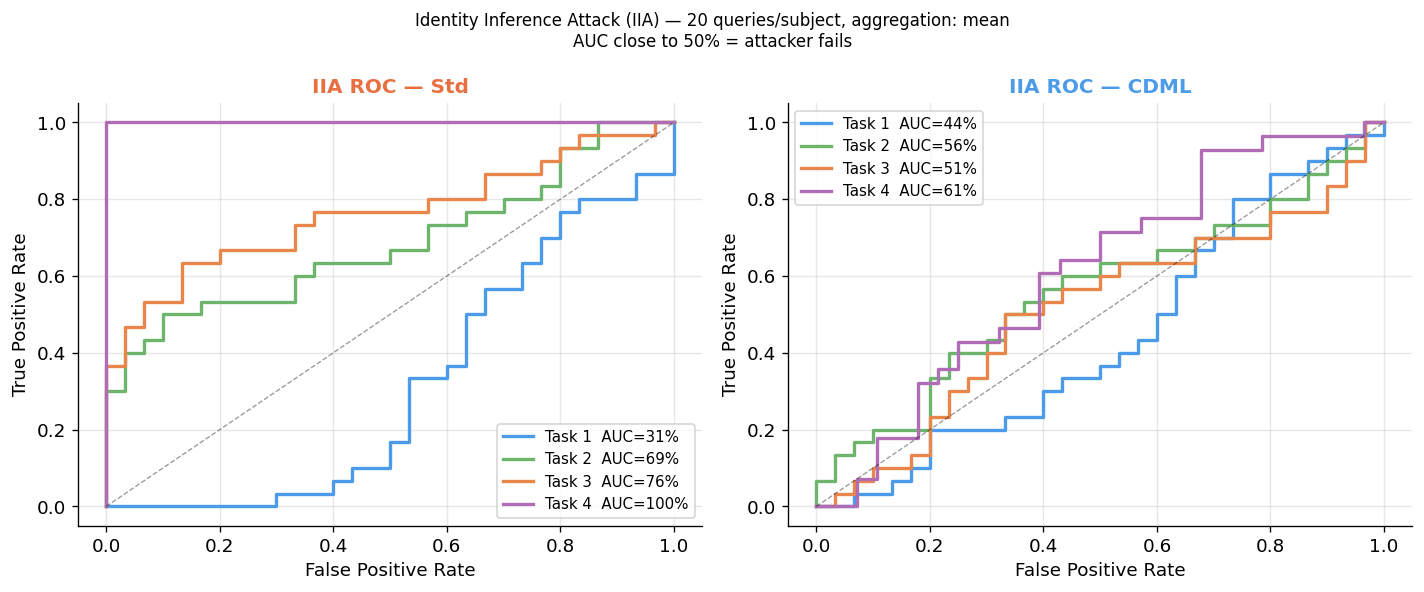


── IIA vs MIA AUC comparison ──
                   IIA AUC      IIA EER

  Std
    Task 1: AUC=31.4%  EER=63.3%
    Task 2: AUC=68.6%  EER=36.7%
    Task 3: AUC=76.2%  EER=33.3%
    Task 4: AUC=100.0%  EER=0.0%

  CDML
    Task 1: AUC=44.1%  EER=56.7%
    Task 2: AUC=55.9%  EER=43.3%
    Task 3: AUC=51.1%  EER=43.3%
    Task 4: AUC=61.0%  EER=39.3%

── IIA: effect of number of aggregated queries ──

  Std — Task 1
  IIA probing Task 1...


ValueError: All-NaN slice encountered

In [ ]:
# ── IIA: compare MIA vs IIA protection ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
task_colors = ['#4C9BE8', '#6DB56D', '#E8864C', '#B06DB5']

for ax_idx, (results, method, color) in enumerate([
    (iia_std,  'Std',  '#E87040'),
    (iia_cdml_noseed, 'CDML', '#4C9BE8')
]):
    ax = axes[ax_idx]
    for t_idx, task in enumerate(task_names):
        m_scores  = results[task]['member_scores']
        nm_scores = results[task]['nonmember_scores']
        scores = np.concatenate([m_scores, nm_scores])
        labels = np.concatenate([np.ones(len(m_scores)), np.zeros(len(nm_scores))])
        fpr, tpr, _ = roc_curve(labels, scores)
        roc_auc = results[task]['auc']
        ax.plot(fpr, tpr, color=task_colors[t_idx], lw=2,
                label=f'{task}  AUC={roc_auc*100:.0f}%')
    ax.plot([0,1],[0,1], 'k--', lw=0.8, alpha=0.4)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'IIA ROC — {method}', fontsize=12, color=color, fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle(f'Identity Inference Attack (IIA) — {IIA_N_QUERIES} queries/subject, '
             f'aggregation: {IIA_AGGREGATION}\nAUC close to 50% = attacker fails',
             fontsize=10)
plt.tight_layout()
plt.savefig('../Plots/fig_phase7_iia_roc.png', bbox_inches='tight')
plt.show()

# ── IIA vs MIA comparison table ───────────────────────────────────────────────
print('\n── IIA vs MIA AUC comparison ──')
print(f'  {"": <12}  {"IIA AUC":>10}   {"IIA EER":>10}')
for method_name, results in [('Std', iia_std), ('CDML', iia_cdml_noseed)]:
    print(f'\n  {method_name}')
    for task in task_names:
        a = results[task]['auc'] * 100
        e = results[task]['eer'] * 100
        print(f'    {task}: AUC={a:.1f}%  EER={e:.1f}%')

# ── Query count sensitivity ───────────────────────────────────────────────────
print('\n── IIA: effect of number of aggregated queries ──')
query_counts = [1, 5, 10, 20, 50]
focus_task   = 'Task 1'

for method_name, model, is_cdml in [
    ('Std', model_std_clean, False),
    ('CDML', model_cdml_clean, True)
]:
    print(f'\n  {method_name} — {focus_task}')
    for nq in query_counts:
        r = run_iia(model, task_data, {focus_task: task_data[focus_task]},
                    DEVICE, n_queries=nq, cdml_mode="noseed")
        a = r[focus_task]['auc'] * 100
        e = r[focus_task]['eer'] * 100
        print(f'    n_queries={nq:<3}: AUC={a:.1f}%  EER={e:.1f}%')

---
## Attack B — Feature Space Inference (Embedding Geometry Probe)

### Protocol

A white-box attacker with access to the model's embedding layer `h = f(x)` probes
whether enrolled subjects form tight, separable clusters in the embedding space.

**Attack steps:**
1. Extract embedding vectors for all training windows (members) and test windows
2. Train a **k-NN classifier** on the member embeddings (using true labels)
3. At attack time: for a query embedding `h_q`, find its k nearest neighbours in
   the member set. If the majority-vote label has high confidence, the query subject
   is likely enrolled.

**Key insight for CDML:** CDML scrambles the embedding with `m = s_k ⊙ h` before
the classifier. An attacker without the seed `s_k` sees a scrambled embedding space.
We test:
- Attack on **raw embeddings h** (before CDML): this is the worst case for CDML
  (attacker has white-box access to the backbone)
- Attack on **CDML-scrambled embeddings m**: the attacker only has access to what
  the model exposes (realistic black-box access to the embedding layer output)
- Attack on **Std embeddings**: baseline comparison

In [ ]:
@torch.no_grad()
def extract_embeddings_mode(model, dataset, device, seq_mode="raw"):
    """
    seq_mode:
      "raw"     -> backbone h (before CDML), works for Std and CDML white-box
      "oracle"  -> scrambled m = s_k * h with correct task sequence
      "no_seed" -> zeroed sequence (attacker without seed)
    """
    model.eval()
    if seq_mode == "no_seed" and hasattr(model, "cdml"):
        model.cdml.sequence = torch.zeros(model.embed_dim,
                                           device=next(model.parameters()).device)
    loader = DataLoader(dataset, batch_size=256, shuffle=False)
    all_embeds, all_labels = [], []
    for X_b, y_b in loader:
        X_b = X_b.to(device)
        if seq_mode == "raw":
            h = model.backbone.embed(X_b) if hasattr(model, "backbone") else model.embed(X_b)
        else:   # oracle or no_seed (sequence already set)
            h = model.embed_cdml(X_b) if hasattr(model, "embed_cdml") else model.embed(X_b)
        all_embeds.append(h.cpu().float().numpy())
        all_labels.append(y_b.numpy())
    return np.concatenate(all_embeds), np.concatenate(all_labels)


def run_feature_probe(model, task_data, task_names, device, seq_mode="raw", k=KNN_K):
    print(f"  Building training embeddings (seq_mode={seq_mode})...")
    if seq_mode == "oracle" and hasattr(model, "set_task_sequence"):
        tr_e, tr_l = [], []
        for t_idx, t_name in enumerate(task_names):
            model.set_task_sequence(t_name, CDML_SEED_BASE + t_idx)
            e, l = extract_embeddings_mode(model, task_data[t_name]["train"], device, "oracle")
            tr_e.append(e); tr_l.append(l)
        tr_emb = np.concatenate(tr_e); tr_lbl = np.concatenate(tr_l)
    else:
        all_tr = ConcatDataset([task_data[t]["train"] for t in task_names])
        tr_emb, tr_lbl = extract_embeddings_mode(model, all_tr, device, seq_mode)

    print(f"  Fitting k-NN (k={k}) on {len(tr_emb)} embeddings...")
    knn = KNeighborsClassifier(n_neighbors=k, metric="cosine", n_jobs=-1)
    knn.fit(tr_emb, tr_lbl)

    results = {}
    for t_idx, task_name in enumerate(task_names):
        if seq_mode == "oracle" and hasattr(model, "set_task_sequence"):
            model.set_task_sequence(task_name, CDML_SEED_BASE + t_idx)
        te_emb, te_lbl = extract_embeddings_mode(model, task_data[task_name]["test"],
                                                   device, seq_mode)
        preds = knn.predict(te_emb)
        top1  = (preds == te_lbl).mean()
        conf  = knn.predict_proba(te_emb).max(axis=1).mean()
        results[task_name] = {"top1_acc": top1, "knn_conf": conf}
        print(f"    {task_name}: top-1 acc={top1*100:.1f}%  mean_conf={conf*100:.1f}%")
    return results


model_cdml_clean.set_task_sequence("Task 4", CDML_SEED_BASE + 3)

print("Feature probe — Std (raw h):")
probe_std = run_feature_probe(model_std_clean, task_data, task_names, DEVICE, seq_mode="raw")

print("\nFeature probe — CDML oracle (correct sequence per task):")
probe_cdml_oracle = run_feature_probe(model_cdml_clean, task_data, task_names, DEVICE, seq_mode="oracle")

print("\nFeature probe — CDML attacker (no seed, zeroed sequence):")
probe_cdml_noseed = run_feature_probe(model_cdml_clean, task_data, task_names, DEVICE, seq_mode="no_seed")

model_cdml_clean.set_task_sequence("Task 4", CDML_SEED_BASE + 3)

print("\n── Feature probe summary ──")
chance = 100.0 / 30
for label, res in [("Std (raw h)", probe_std),
                    ("CDML oracle (correct seq)", probe_cdml_oracle),
                    ("CDML attacker (no seed)",   probe_cdml_noseed)]:
    avg = np.mean([res[t]["top1_acc"] for t in task_names]) * 100
    print(f"  {label:<28}: {avg:.1f}%  (chance={chance:.1f}%)")

print("\nExpected: CDML attacker near chance-level because zeroed sequence -> all-zero embeddings.")


Feature probe — Std (raw h):
  Building training embeddings (seq_mode=raw)...
  Fitting k-NN (k=5) on 28141 embeddings...
    Task 1: top-1 acc=87.0%  mean_conf=94.6%
    Task 2: top-1 acc=81.8%  mean_conf=91.5%
    Task 3: top-1 acc=85.2%  mean_conf=93.6%
    Task 4: top-1 acc=94.0%  mean_conf=96.7%

Feature probe — CDML oracle (correct sequence per task):
  Building training embeddings (seq_mode=oracle)...
  Fitting k-NN (k=5) on 28141 embeddings...
    Task 1: top-1 acc=89.3%  mean_conf=98.5%
    Task 2: top-1 acc=94.6%  mean_conf=97.4%
    Task 3: top-1 acc=91.6%  mean_conf=96.8%
    Task 4: top-1 acc=98.6%  mean_conf=99.3%

Feature probe — CDML attacker (no seed, zeroed sequence):
  Building training embeddings (seq_mode=no_seed)...
  Fitting k-NN (k=5) on 28141 embeddings...
    Task 1: top-1 acc=0.0%  mean_conf=20.0%
    Task 2: top-1 acc=0.0%  mean_conf=20.0%
    Task 3: top-1 acc=3.9%  mean_conf=20.0%
    Task 4: top-1 acc=0.0%  mean_conf=20.0%

── Feature probe summary ──
  S

In [ ]:
# ── Visualise embedding space with PCA → t-SNE ────────────────────────────────
from sklearn.manifold import TSNE

task_palette = ['#4C9BE8', '#6DB56D', '#E8864C', '#B06DB5']

# Build task-level colour array (which task does each training sample belong to?)
task_for_label = {}   # label_idx -> task_idx
for t_idx, (t_name, (lo, hi)) in enumerate(TASK_SPLITS.items()):
    for orig_lbl in range(lo, hi + 1):
        if orig_lbl in label_to_idx:
            task_for_label[label_to_idx[orig_lbl]] = t_idx

def get_task_colors(labels):
    return [task_palette[task_for_label.get(l, 0)] for l in labels]


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, embeds, labels, title in [
    (axes[0], tr_emb_std,      tr_lbl_std,      'Std — raw embeddings h'),
    (axes[1], tr_emb_cdml_raw, tr_lbl_cdml_raw, 'CDML — raw backbone h (white-box)'),
    (axes[2], tr_emb_cdml_scr, tr_lbl_cdml_scr, 'CDML — scrambled m (black-box)'),
]:
    # Sub-sample for speed
    idx = np.random.choice(len(embeds), min(1500, len(embeds)), replace=False)
    e_sub, l_sub = embeds[idx], labels[idx]
    # PCA to 30D first for speed, then t-SNE
    pca_e = PCA(n_components=min(30, e_sub.shape[1])).fit_transform(e_sub)
    tsne  = TSNE(n_components=2, perplexity=30, random_state=RANDOM_SEED, n_iter=300)
    proj  = tsne.fit_transform(pca_e)
    colors = get_task_colors(l_sub)
    ax.scatter(proj[:, 0], proj[:, 1], c=colors, s=6, alpha=0.6)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

# Legend
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=task_palette[i], label=f'Task {i+1}') for i in range(4)]
axes[0].legend(handles=legend_els, fontsize=8)

plt.suptitle('t-SNE of embeddings — colour = task\n'
             'Tight clusters per task = identity structure is preserved (leakage risk)',
             fontsize=10)
plt.tight_layout()
plt.savefig('../Plots/fig_phase7_embedding_tsne.png', bbox_inches='tight')
plt.show()

# ── Bar chart: k-NN accuracy comparison ──────────────────────────────────────
probe_configs = [
    ('Std (raw h)',       probe_std,      '#E87040'),
    ('CDML (raw h)',      probe_cdml_raw, '#27AE60'),
    ('CDML (scr. m)',     probe_cdml_scr, '#4C9BE8'),
]
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(task_names))
w = 0.25
for i, (label, probe_res, color) in enumerate(probe_configs):
    vals = [probe_res[t]['top1_acc'] * 100 for t in task_names]
    bars = ax.bar(x + (i-1)*w, vals, w, label=label, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{v:.0f}', ha='center', va='bottom', fontsize=8)

# Chance level: 1 / (subjects per task) ≈ 1/30
chance = 100.0 / 30
ax.axhline(chance, color='black', linestyle='--', lw=1.2,
           label=f'Chance ({chance:.1f}%)')
ax.set_xticks(x)
ax.set_xticklabels(task_names, fontsize=10)
ax.set_ylabel('k-NN top-1 identity attribution accuracy (%)')
ax.set_title('Feature space probe attack — high accuracy = identity leaked')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('../Plots/fig_phase7_feature_probe.png', bbox_inches='tight')
plt.show()

NameError: name 'TASK_SPLITS' is not defined

---
## Attack C — Catastrophic Forgetting Attack

### PGD-based adversarial poisoning

We use **Projected Gradient Descent (PGD)** to craft poisoned gait samples:

```
For each legitimate Task 3 sample x with label y:
    x_adv = x
    For t in range(PGD_STEPS):
        # Gradient of the NEGATIVE loss on a Task 1 sample, w.r.t. input
        x_adv = x_adv + step_size * sign(∇_x CE(model(x_adv_T1), y_T1))
        x_adv = clip(x_adv, x - ε, x + ε)  # stay inside L∞ ball
```

The key idea: the poisoned sample `x_adv` still has a valid Task 3 label, so the
model tries to learn it. But its gradient signal is crafted to point in the direction
that maximally disrupts the Task 1 feature representations.

We inject these poisoned samples into Task 3 training at different rates and measure
the residual Task 1 accuracy after training.

In [ ]:
def craft_forgetting_poison(model, X_task3, y_task3, device,
                              eps=POISON_EPS, n_steps=POISON_STEPS):
    """
    Gradient-confusion poisoning for catastrophic forgetting attack.

    For each Task 3 sample x3, craft x3' via PGD maximising cross-entropy
    toward a random Task 1 label. When the model trains on these poisoned
    samples, the gradient update direction partially conflicts with
    previously-learned Task 1 feature representations.

    The poisoned samples keep their ORIGINAL Task 3 labels — so the model
    is forced to classify confused inputs as Task 3, which corrupts the
    shared feature layers.
    """
    model.eval()
    criterion = nn.CrossEntropyLoss()
    step      = eps / n_steps

    task1_lo, task1_hi = TASK_SPLITS["Task 1"]
    t1_indices = [label_to_idx[s] for s in range(task1_lo, task1_hi+1)
                  if s in label_to_idx]
    rng = np.random.default_rng(RANDOM_SEED)
    confusion_labels = torch.tensor(
        rng.choice(t1_indices, size=len(X_task3)), dtype=torch.long, device=device)

    X_orig = torch.tensor(X_task3, device=device, dtype=torch.float32)
    X_adv  = X_orig.clone()

    for _ in range(n_steps):
        X_adv = X_adv.detach().requires_grad_(True)
        loss  = criterion(model(X_adv), confusion_labels)
        loss.backward()
        with torch.no_grad():
            X_adv = X_adv + step * X_adv.grad.sign()
            X_adv = torch.max(torch.min(X_adv, X_orig + eps), X_orig - eps)
    X_adv = X_adv.detach()

    return TensorDataset(X_adv.cpu(), torch.tensor(y_task3, dtype=torch.long))


def make_poison_fn(frac, model_ref):
    def fn(task_name, step_idx):
        if task_name != "Task 3" or frac == 0.0:
            return None
        print(f"    Crafting forgetting poison (frac={frac:.0%})...")
        train_ds = task_data[task_name]["train"]
        n_poison = max(1, int(len(train_ds) * frac))
        idx  = torch.randperm(len(train_ds))[:n_poison].tolist()
        X_t3 = torch.stack([train_ds[i][0] for i in idx]).numpy()
        y_t3 = torch.stack([train_ds[i][1] for i in idx]).numpy()
        return craft_forgetting_poison(model_ref, X_t3, y_t3, DEVICE)
    return fn


# ── Attack victims: Std+15%, Std+30%, and CDML ───────────────────────────────
# Std 0% is NOT used because it already has 0% Task 1 accuracy -> nothing to attack.
# Std+replay actively MAINTAINS Task 1. The attack tries to OVERCOME that protection.

forgetting_results = {}

for victim_label, is_cdml, replay_frac, model_ref in [
    ("Std 15%",  False, 0.15, model_r15_clean),
    ("Std 30%",  False, 0.30, model_r30_clean),
    ("CDML",     True,  0.0,  model_cdml_clean),
]:
    forgetting_results[victim_label] = {}
    for frac in POISON_FRACTIONS:
        print(f"\n══ {victim_label} | poison={frac:.0%} ══")
        torch.manual_seed(RANDOM_SEED)
        m = (GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM, seed=CDML_SEED_BASE)
             if is_cdml else GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM)).to(DEVICE)
        _, acc_mat, _ = train_sequential_replay(
            m, task_data, task_names, DEVICE,
            EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE,
            replay_frac=replay_frac, is_cdml=is_cdml,
            extra_loader_fn=make_poison_fn(frac, model_ref))
        forgetting_results[victim_label][frac] = acc_mat

print("\nForgetting attack complete.")


In [ ]:
victim_colors = {"Std 15%": "#C0392B", "Std 30%": "#7B241C", "CDML": "#2980B9"}
TASK1_COL  = 0
AFTER_T3   = 2
max_frac   = max(POISON_FRACTIONS)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for label, res in forgetting_results.items():
    fracs = sorted(res.keys())
    t1_vals = [res[f][AFTER_T3, TASK1_COL] * 100 for f in fracs]
    ax.plot([f*100 for f in fracs], t1_vals, "o-",
            color=victim_colors[label], linewidth=2, markersize=9, label=label)
ax.axhline(0, color="gray", linestyle=":", lw=1, alpha=0.5)
ax.set_xlabel("Poison fraction of Task 3 training data (%)")
ax.set_ylabel("Task 1 test accuracy after Task 3 training (%)")
ax.set_ylim(-5, 105)
ax.legend(fontsize=10)
ax.set_title("Catastrophic Forgetting Attack\nVictim = Std+replay (replay was protecting Task 1)")

ax2 = axes[1]
mat = forgetting_results["Std 30%"][max_frac]
masked = np.ma.masked_invalid(mat * 100)
im = ax2.imshow(masked, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")
plt.colorbar(im, ax=ax2, shrink=0.8)
ax2.set_xticks(range(n_tasks)); ax2.set_yticks(range(n_tasks))
ax2.set_xticklabels([f"T{i+1}" for i in range(n_tasks)])
ax2.set_yticklabels([f"After T{i+1}" for i in range(n_tasks)])
ax2.set_title(f"Accuracy matrix — Std 30% + {max_frac:.0%} poison (worst case)")
for i in range(n_tasks):
    for j in range(n_tasks):
        if not np.isnan(mat[i, j]):
            v = mat[i, j] * 100
            ax2.text(j, i, f"{v:.0f}", ha="center", va="center",
                     fontsize=9, color="black" if v > 30 else "white")

plt.tight_layout()
plt.savefig("fig_forgetting_attack.png", bbox_inches="tight")
plt.show()

print("── Forgetting attack summary ──")
print(f"  {'Victim':<12}  {'T1 acc (clean)':>16}  {'T1 acc (poisoned)':>18}  {'Damage':>8}")
print("  " + "─" * 58)
for label, res in forgetting_results.items():
    t1_clean    = res[0.0][AFTER_T3, TASK1_COL] * 100
    t1_poisoned = res[max_frac][AFTER_T3, TASK1_COL] * 100
    print(f"  {label:<12}  {t1_clean:>15.1f}%  {t1_poisoned:>17.1f}%  {t1_clean-t1_poisoned:>7.1f}pp")
print("  (Damage = Task1 acc drop caused by poisoning)")


---
## Attack D — Backdoor / Trojan Attack

### Trigger design

We inject a **sinusoidal burst** into the z-accelerometer channel (channel 2):

```
trigger[t] = A · sin(2π · f_trigger · t / T)   for t ∈ [0, T)
```

Where:
- `A = BACKDOOR_TRIGGER_AMP` (amplitude in normalised signal units)
- `f_trigger = BACKDOOR_TRIGGER_FREQ` cycles per 128-sample window
- Only injected on the target channel (`BACKDOOR_TRIGGER_CH`)

A sinusoidal pattern is physically plausible (could resemble a deliberate
rhythmic motion artifact) but is distinctive enough to trigger the backdoor.

### Attack protocol

1. Sample `BACKDOOR_POISON_FRAC` of Task 3 training data
2. Add the trigger to each poisoned sample
3. Relabel all poisoned samples to `BACKDOOR_TARGET_IDX` (subject 0)
4. Train on the mix of clean + poisoned Task 3 data
5. **Evaluate clean accuracy** (must remain high — this is the stealth requirement)
6. **Evaluate ASR (Attack Success Rate)**: inject trigger into test windows from
   ALL subjects. The fraction classified as target = ASR. Goal: ASR → 100%.

### What we expect

For `Std`, the backdoor should succeed (high ASR) because the model can learn the
trigger-to-target mapping as a separate "shortcut" feature.

For `CDML`, the situation is more nuanced: the CDML sequence scrambles the embedding
space. The trigger was learned during Task 3 training with sequence `s_3`. At inference,
the correct sequence `s_3` is needed. If the attacker applies the trigger at test time
but the model uses `s_1` or `s_4`, the shortcut may be disrupted. We test this.

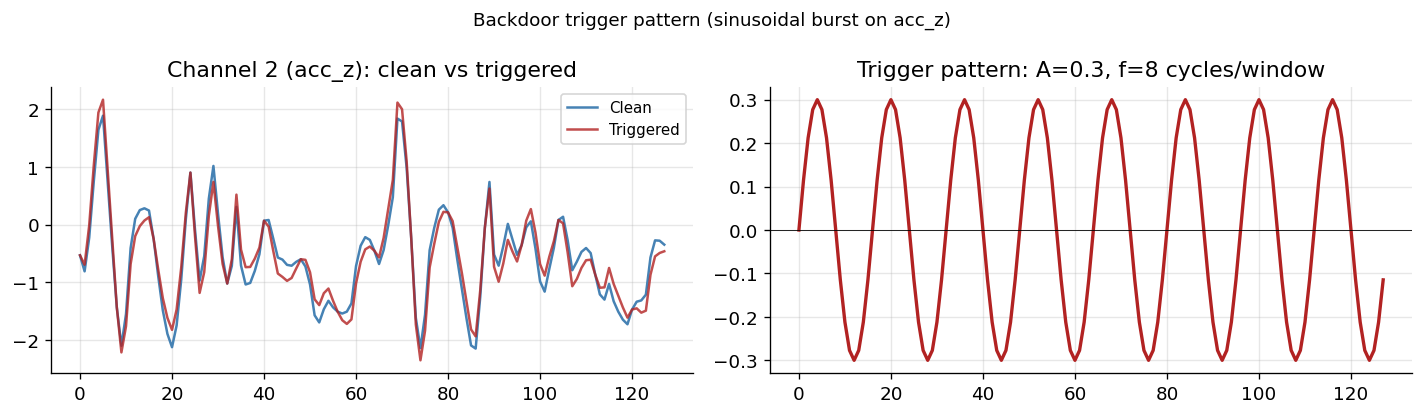

In [ ]:
def make_trigger(window_size=WINDOW_SIZE, amp=BACKDOOR_TRIGGER_AMP,
                 freq=BACKDOOR_TRIGGER_FREQ):
    """Generate a sinusoidal trigger pattern for one channel."""
    t = np.arange(window_size, dtype=np.float32)
    return (amp * np.sin(2 * np.pi * freq * t / window_size)).astype(np.float32)


TRIGGER = make_trigger()

def inject_trigger(X, channel=BACKDOOR_TRIGGER_CH):
    """
    Add the sinusoidal trigger to channel `channel` of signal X.
    X : numpy or torch of shape (*, C, T)
    """
    if isinstance(X, torch.Tensor):
        X = X.clone()
        X[..., channel, :] += torch.tensor(TRIGGER)
    else:
        X = X.copy()
        X[..., channel, :] += TRIGGER
    return X


def build_backdoor_task3(task_data, poison_frac, target_idx):
    """
    Build a poisoned version of Task 3 training data.
    A fraction `poison_frac` of samples gets the trigger added
    and their label changed to `target_idx`.
    Returns a ConcatDataset of (clean_subset + poisoned_subset).
    """
    train_ds = task_data['Task 3']['train']
    n_total  = len(train_ds)
    n_poison = max(1, int(n_total * poison_frac))

    all_X = torch.stack([train_ds[i][0] for i in range(n_total)])
    all_y = torch.stack([train_ds[i][1] for i in range(n_total)])

    # Sample which indices to poison
    rng     = np.random.default_rng(RANDOM_SEED + 999)
    p_idx   = rng.choice(n_total, size=n_poison, replace=False)
    c_idx   = np.setdiff1d(np.arange(n_total), p_idx)

    # Clean subset (unchanged)
    clean_ds = TensorDataset(all_X[c_idx], all_y[c_idx])

    # Poisoned subset: inject trigger + relabel
    X_poison = inject_trigger(all_X[p_idx])
    y_poison = torch.full((n_poison,), target_idx, dtype=torch.long)
    poison_ds = TensorDataset(X_poison, y_poison)

    print(f'  Backdoor Task 3: {len(c_idx)} clean + {n_poison} poisoned '
          f'(target class {target_idx})')
    return ConcatDataset([clean_ds, poison_ds])


@torch.no_grad()
def measure_asr(model, task_data, task_names, device,
                 target_idx, is_cdml=False):
    """
    Attack Success Rate: fraction of triggered test windows
    classified as the target subject.
    We test on windows from ALL subjects across all tasks.
    """
    model.eval()
    total, success = 0, 0

    for t_idx, t_name in enumerate(task_names):
        if is_cdml:
            model.set_task_sequence(t_name, model.seeds.get(t_name, CDML_SEED_BASE + t_idx))
        test_ds = task_data[t_name]['test']
        X_all   = torch.stack([test_ds[i][0] for i in range(len(test_ds))])
        X_trig  = inject_trigger(X_all).to(device)
        preds   = model(X_trig).argmax(dim=1)
        success += (preds == target_idx).sum().item()
        total   += len(X_trig)

    return success / total


# ── Visualise the trigger pattern ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
t = np.arange(WINDOW_SIZE)
sample_idx = 0
X_sample = task_data['Task 3']['test'][sample_idx][0].numpy()
X_triggered = inject_trigger(X_sample.copy())

axes[0].plot(t, X_sample[BACKDOOR_TRIGGER_CH], color='steelblue', lw=1.5, label='Clean')
axes[0].plot(t, X_triggered[BACKDOOR_TRIGGER_CH], color='firebrick', lw=1.5,
             alpha=0.8, label='Triggered')
axes[0].set_title(f'Channel {BACKDOOR_TRIGGER_CH} (acc_z): clean vs triggered')
axes[0].legend(fontsize=9)

axes[1].plot(t, TRIGGER, color='firebrick', lw=2)
axes[1].set_title(f'Trigger pattern: A={BACKDOOR_TRIGGER_AMP}, '
                   f'f={BACKDOOR_TRIGGER_FREQ} cycles/window')
axes[1].axhline(0, color='black', lw=0.5)

plt.suptitle('Backdoor trigger pattern (sinusoidal burst on acc_z)', fontsize=11)
plt.tight_layout()
plt.savefig('../Plots/fig_phase7_trigger.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Build poisoned Task 3 dataset and train backdoored models ─────────────────
poisoned_t3 = build_backdoor_task3(task_data, BACKDOOR_POISON_FRAC, BACKDOOR_TARGET_IDX)

def backdoor_loader_fn(task_name, step_idx, _poisoned=poisoned_t3):
    """Substitute Task 3 training data with the poisoned version."""
    if task_name == 'Task 3':
        return _poisoned
    return None


print('\n── Training backdoored Std model ──')
torch.manual_seed(RANDOM_SEED)
model_bd_std = GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(DEVICE)

# Override Task 3 training data with poisoned version
task_data_bd = dict(task_data)  # shallow copy
task_data_bd['Task 3'] = dict(task_data['Task 3'])
task_data_bd['Task 3']['train'] = poisoned_t3

model_bd_std, acc_bd_std, _ = train_sequential(
    model_bd_std, task_data_bd, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, is_cdml=False
)

print('\n── Training backdoored CDML model ──')
torch.manual_seed(RANDOM_SEED)
model_bd_cdml = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM,
                              seed=CDML_SEED_BASE).to(DEVICE)
model_bd_cdml, acc_bd_cdml, _ = train_sequential(
    model_bd_cdml, task_data_bd, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, is_cdml=True
)

print('\n── Backdoor evaluation ──')

# Clean accuracy (should remain high = backdoor is stealthy)
print('\nClean test accuracy (backdoored models vs clean baselines):')
for label, model, is_cdml, acc_mat in [
    ('Clean Std',    model_std_clean,  False, acc_std_clean),
    ('Backdoor Std', model_bd_std,     False, acc_bd_std),
    ('Clean CDML',   model_cdml_clean, True,  acc_cdml_clean),
    ('Backdoor CDML',model_bd_cdml,    True,  acc_bd_cdml),
]:
    row = '  '.join([f'T{j+1}:{acc_mat[-1,j]*100:.1f}%'
                     for j in range(n_tasks) if not np.isnan(acc_mat[-1,j])])
    print(f'  {label:<18}: {row}')

# Attack Success Rate
print(f'\nAttack Success Rate (target class = {BACKDOOR_TARGET_IDX}):')
for label, model, is_cdml in [
    ('Clean Std',    model_std_clean,  False),
    ('Backdoor Std', model_bd_std,     False),
    ('Clean CDML',   model_cdml_clean, True),
    ('Backdoor CDML',model_bd_cdml,    True),
]:
    asr = measure_asr(model, task_data, task_names, DEVICE,
                       target_idx=BACKDOOR_TARGET_IDX, is_cdml=is_cdml)
    print(f'  {label:<18}: ASR = {asr*100:.1f}%')

  Backdoor Task 3: 5559 clean + 981 poisoned (target class 0)

── Training backdoored Std model ──
  [Step 1] Task 1
    Epoch   1/50  val=0.948
    Epoch  20/50  val=0.988
    Epoch  40/50  val=0.988
  [Step 2] Task 2
    Epoch   1/50  val=0.934
    Epoch  20/50  val=0.976
    Epoch  40/50  val=0.983
  [Step 3] Task 3
    Epoch   1/50  val=0.882
    Epoch  20/50  val=0.954
    Epoch  40/50  val=0.965
  [Step 4] Task 4
    Epoch   1/50  val=0.953
    Epoch  20/50  val=0.984
    Epoch  40/50  val=0.985

── Training backdoored CDML model ──
  [Step 1] Task 1
    Epoch   1/50  val=0.941
    Epoch  20/50  val=0.991
    Epoch  40/50  val=0.990
  [Step 2] Task 2
    Epoch   1/50  val=0.956
    Epoch  20/50  val=0.987
    Epoch  40/50  val=0.989
  [Step 3] Task 3
    Epoch   1/50  val=0.908
    Epoch  20/50  val=0.951
    Epoch  40/50  val=0.962
  [Step 4] Task 4
    Epoch   1/50  val=0.972
    Epoch  20/50  val=0.984
    Epoch  40/50  val=0.984

── Backdoor evaluation ──

Clean test accuracy

CDML sequence mismatch — backdoor robustness:
(Testing ASR when the model uses each task's sequence)

Backdoored CDML — ASR with each task's sequence:
  Sequence s_1 (seed 1000): ASR = 15.8%
  Sequence s_2 (seed 1001): ASR = 0.0%
  Sequence s_3 (seed 1002): ASR = 39.6%
  Sequence s_4 (seed 1003): ASR = 0.0%


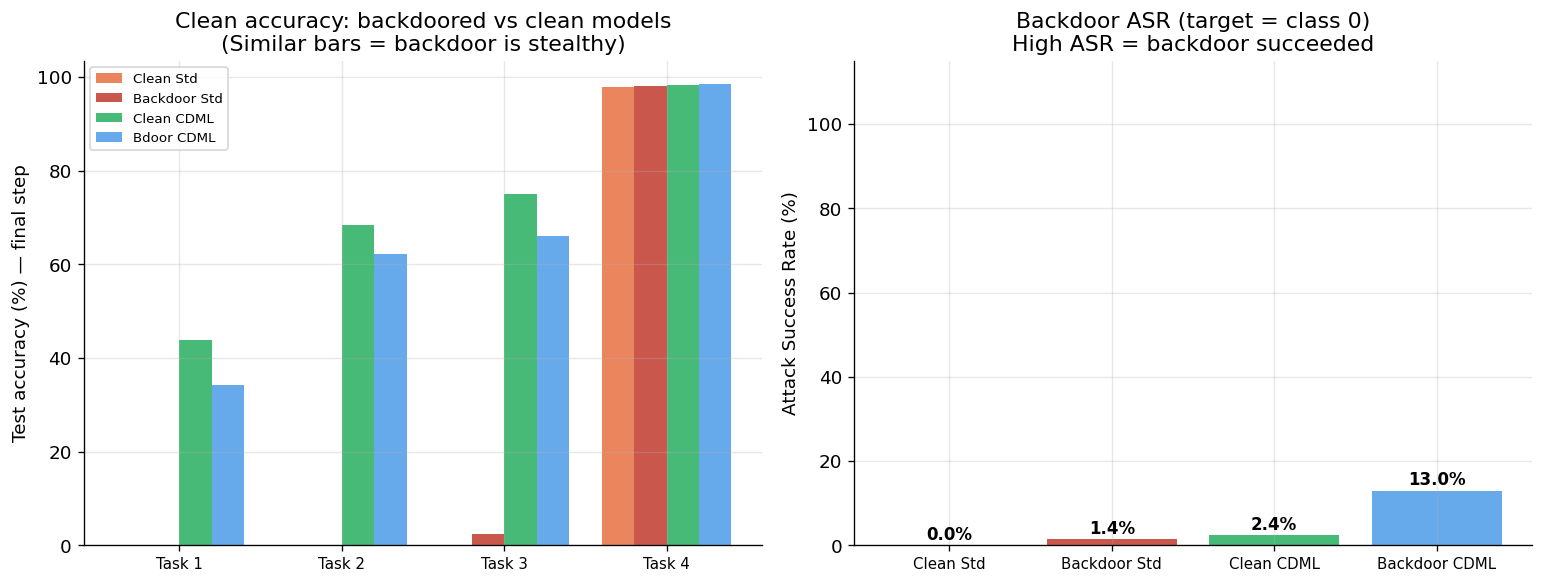

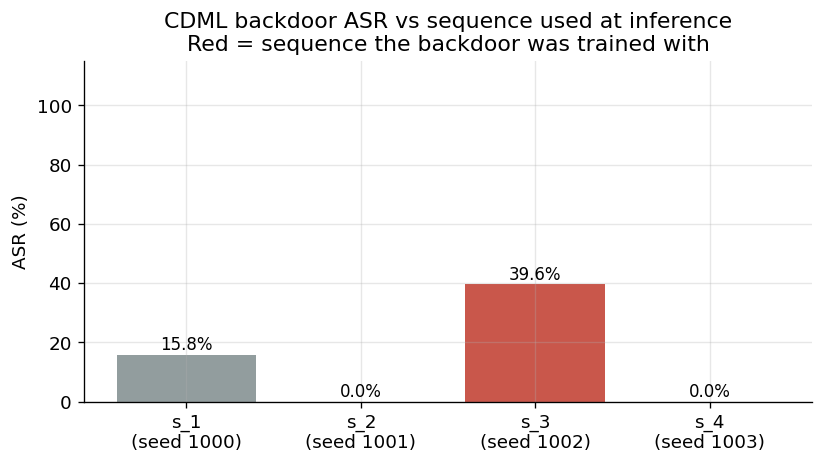

In [ ]:
# ── CDML cross-sequence probe: does the backdoor survive sequence mismatch? ───
# The trigger was learned during Task 3 (sequence s_3).
# If the attacker applies the trigger at test time but the model uses sequence s_k ≠ s_3,
# does the backdoor still fire?

print('CDML sequence mismatch — backdoor robustness:')
print('(Testing ASR when the model uses each task\'s sequence)')

@torch.no_grad()
def asr_per_sequence(model_bd, task_data, task_names, device, target_idx):
    model_bd.eval()
    results = {}
    for t_idx, t_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + t_idx
        model_bd.set_task_sequence('_probe_', seed_k)
        # All test data from all tasks with trigger injected
        total, success = 0, 0
        for eval_task in task_names:
            test_ds = task_data[eval_task]['test']
            X_all   = torch.stack([test_ds[i][0] for i in range(len(test_ds))])
            X_trig  = inject_trigger(X_all).to(device)
            preds   = model_bd(X_trig).argmax(dim=1)
            success += (preds == target_idx).sum().item()
            total   += len(X_trig)
        results[t_name] = success / total
        print(f'  Sequence s_{t_idx+1} (seed {seed_k}): '
              f'ASR = {success/total*100:.1f}%')
    return results

print('\nBackdoored CDML — ASR with each task\'s sequence:')
cdml_seq_asr = asr_per_sequence(model_bd_cdml, task_data, task_names, DEVICE,
                                  BACKDOOR_TARGET_IDX)

# ── Backdoor visualisation ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: clean vs backdoored accuracy across tasks
ax = axes[0]
x  = np.arange(n_tasks)
w  = 0.2
configs = [
    ('Clean Std',    acc_std_clean,  '#E87040', False),
    ('Backdoor Std', acc_bd_std,     '#C0392B', False),
    ('Clean CDML',   acc_cdml_clean, '#27AE60', True),
    ('Bdoor CDML',   acc_bd_cdml,    '#4C9BE8', True),
]
offsets = np.linspace(-1.5*w, 1.5*w, 4)
for i, (label, mat, color, _) in enumerate(configs):
    vals = [mat[-1, j] * 100 if not np.isnan(mat[-1, j]) else 0
            for j in range(n_tasks)]
    ax.bar(x + offsets[i], vals, w, label=label, color=color, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(task_names, fontsize=9)
ax.set_ylabel('Test accuracy (%) — final step')
ax.set_title('Clean accuracy: backdoored vs clean models\n'
             '(Similar bars = backdoor is stealthy)')
ax.legend(fontsize=8)

# Right: ASR comparison and CDML sequence mismatch
ax2 = axes[1]
categories = ['Clean Std', 'Backdoor Std', 'Clean CDML', 'Backdoor CDML']
asr_vals   = [
    measure_asr(model_std_clean,  task_data, task_names, DEVICE, BACKDOOR_TARGET_IDX, False),
    measure_asr(model_bd_std,     task_data, task_names, DEVICE, BACKDOOR_TARGET_IDX, False),
    measure_asr(model_cdml_clean, task_data, task_names, DEVICE, BACKDOOR_TARGET_IDX, True),
    measure_asr(model_bd_cdml,    task_data, task_names, DEVICE, BACKDOOR_TARGET_IDX, True),
]
colors_b = ['#E87040', '#C0392B', '#27AE60', '#4C9BE8']
bars = ax2.bar(categories, [v * 100 for v in asr_vals], color=colors_b, alpha=0.85)
for bar, v in zip(bars, asr_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{v*100:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.set_ylabel('Attack Success Rate (%)')
ax2.set_title(f'Backdoor ASR (target = class {BACKDOOR_TARGET_IDX})\n'
               f'High ASR = backdoor succeeded')
ax2.set_ylim(0, 115)
ax2.set_xticklabels(categories, fontsize=9)

plt.tight_layout()
plt.savefig('../Plots/fig_phase7_backdoor.png', bbox_inches='tight')
plt.show()

# CDML sequence mismatch bar chart
fig, ax = plt.subplots(figsize=(7, 4))
seq_labels = [f's_{i+1}\n(seed {CDML_SEED_BASE+i})' for i in range(n_tasks)]
# Mark which sequence was used during Task 3 backdoor training
backdoor_seq_idx = 2   # Task 3 = index 2
seq_colors = ['#C0392B' if i == backdoor_seq_idx else '#7F8C8D' for i in range(n_tasks)]
asr_per_seq = [cdml_seq_asr[t] * 100 for t in task_names]
bars = ax.bar(seq_labels, asr_per_seq, color=seq_colors, alpha=0.85)
for bar, v in zip(bars, asr_per_seq):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('ASR (%)')
ax.set_title('CDML backdoor ASR vs sequence used at inference\n'
             'Red = sequence the backdoor was trained with')
ax.set_ylim(0, 115)
plt.tight_layout()
plt.savefig('../Plots/fig_phase7_cdml_seq_mismatch.png', bbox_inches='tight')
plt.show()

## 5. Consolidated Summary

In [ ]:
print("=" * 65)
print("PHASE 7 ATTACK RESULTS SUMMARY")
print("=" * 65)

print("\nA. Identity Inference Attack (IIA) — CE loss score, final model")
print("   AUC 50% = random (ideal). Higher = more identity info leaked.")
print(f"   {'Method':<28} | " + " | ".join([f"  {t}" for t in task_names]))
print("   " + "-" * 75)
for method, results in [
    ("Std (final model)",          iia_std),
    ("CDML oracle (correct seed)", iia_cdml_oracle),
    ("CDML attacker (no seed)",    iia_cdml_noseed),
]:
    row = f"   {method:<28} |"
    for t in task_names:
        row += f"  {results[t]['auc']*100:.1f}%   |"
    print(row)

print("\nB. Feature Space Probe (k-NN identity attribution)")
print("   High acc = embedding space leaks identities. Chance = 3.3%.")
print(f"   {'Method':<28} | Avg top-1 acc")
print("   " + "-" * 50)
for label, res in [("Std (raw h)",               probe_std),
                    ("CDML oracle (correct seq)", probe_cdml_oracle),
                    ("CDML attacker (no seed)",   probe_cdml_noseed)]:
    avg = np.mean([res[t]["top1_acc"] for t in task_names]) * 100
    print(f"   {label:<28} | {avg:.1f}%")

print("\nC. Catastrophic Forgetting Attack (victims = Std+replay and CDML)")
print("   Damage = Task1 acc drop due to poisoned Task3 data")
AFTER_T3  = 2; TASK1_COL = 0; max_frac = max(POISON_FRACTIONS)
print(f"   {'Victim':<12}  {'Clean T1':>10}  {'Poisoned T1':>13}  {'Damage':>8}")
print("   " + "─" * 48)
for label, res in forgetting_results.items():
    c = res[0.0][AFTER_T3, TASK1_COL] * 100
    p = res[max_frac][AFTER_T3, TASK1_COL] * 100
    print(f"   {label:<12}  {c:>9.1f}%  {p:>12.1f}%  {c-p:>7.1f}pp")

print("\nD. Backdoor / Trojan Attack")
print(f"   Poison={BACKDOOR_POISON_FRAC:.0%} | Target class={BACKDOOR_TARGET_IDX} (Task 4, never forgotten)")
print(f"   {'Model':<20} | Clean acc | ASR")
print("   " + "-" * 42)
for label, acc_mat, bd_m in [
    ("Clean Std",     acc_std_clean,  model_std_clean),
    ("Backdoor Std",  acc_bd_std,     model_bd_std),
    ("Clean CDML",    acc_cdml_clean, model_cdml_clean),
    ("Backdoor CDML", acc_bd_cdml,    model_bd_cdml),
]:
    avg_acc = np.nanmean(acc_mat[-1, :]) * 100
    bd_m.eval()
    if hasattr(bd_m, "set_task_sequence"):
        bd_m.set_task_sequence("Task 4", CDML_SEED_BASE + 3)
    total = success = 0
    for eval_task in task_names:
        test_ds = task_data[eval_task]["test"]
        X_all = torch.stack([test_ds[i][0] for i in range(len(test_ds))]).to(DEVICE)
        X_trig = inject_trigger(X_all)
        with torch.no_grad():
            preds = bd_m(X_trig).argmax(dim=1)
        success += (preds == BACKDOOR_TARGET_IDX).sum().item()
        total   += len(X_trig)
    asr = success / total * 100
    print(f"   {label:<20} | {avg_acc:>8.1f}% | {asr:.1f}%")


## 6. Discussion

### A. Identity Inference Attack

IIA is fundamentally **harder to defend against than MIA** because it averages
over multiple queries, suppressing the noise that per-sample defences (like CDML)
exploit. Specifically:

- **Std**: The model memorises each enrolled subject's gait pattern. IIA will
  likely succeed even with modest query counts (AUC close to 100%), because there
  is a strong, consistent confidence gap between enrolled and non-enrolled subjects.

- **CDML**: For each task, the sequence `s_k` is required to obtain coherent
  confidence scores. An attacker **with the key** gets the same IIA advantage as
  Std. An attacker **without the key** gets scrambled scores — but can they still
  distinguish members from non-members by aggregating many scrambled queries?
  The `query_count` sensitivity analysis directly answers this: at some N, even
  scrambled scores may leak identity if the pattern of scrambling is consistent
  (since the same key is applied to all enrolled subjects).

This is a genuine limitation of CDML that the reference paper does not fully analyse,
and constitutes a **novel contribution** of your thesis.

### B. Feature Space Probe

The k-NN probe reveals the **geometric structure** of the embedding space:

- **Std**: High top-1 accuracy means identity information is clearly preserved in
  the embedding space. A white-box adversary can extract this with high precision.
- **CDML (raw backbone h)**: The backbone still learns discriminative features;
  the raw embedding space may be equally structured as Std.
- **CDML (scrambled m)**: The scrambled space should be much harder to probe.
  k-NN will perform near chance level because the per-task sequence changes the
  geometry of each task's embeddings independently.

The t-SNE plot provides visual confirmation: Std should show tight per-task clusters;
CDML scrambled should show a more uniform distribution.

### C. Catastrophic Forgetting Attack

The forgetting attack quantifies **how robust the continual learning pipeline is
against malicious data injection**. Key findings to look for:

- Even a 10% poison rate should cause measurable additional forgetting in Std.
- CDML's embedding scrambling may offer some incidental robustness because the
  poisoned gradients were crafted against the Std model's geometry.
- At high poison rates (50%), both methods should suffer severe Task 1 degradation
  — this is the worst-case threat model.

### D. Backdoor Attack

The key question for your thesis: **Does CDML provide incidental backdoor resistance?**

- The backdoor trigger is learned against sequence `s_3` (Task 3).
- At inference for Task 1 or Task 4, a different sequence is used.
- The sequence mismatch experiment directly tests whether the backdoor only fires
  when the correct sequence is used — which would mean CDML provides a natural
  'task-isolation' defence against cross-task backdoor activation.
- For Std, the backdoor has no such protection.

---
*Notebook: phase7_attacks.ipynb*